# Notebook 3 — Generalised projectile **with air drag**
### RK4 ground truth · a PINN over (θ, k) · sensitivity analysis · research log

**Why this notebook is a real step up.** In Notebooks 1 and 2 I worked in a vacuum: clean
parabolas, and an exact formula to check against. Here I add **air resistance**, and that
single change breaks everything that made the earlier notebooks comfortable. I think this is
the most interesting notebook in my project, so I want to be careful about the reasoning.

**My physics.** A projectile in air feels gravity *and* drag, where drag always opposes the
velocity. For everyday objects (a ball, a stone) drag scales with speed *squared*
("quadratic drag"). Writing the drag-per-unit-mass as $k$ and the speed as
$v=\sqrt{v_x^2+v_y^2}$, my equations of motion become a **coupled, nonlinear system**:
$$ \dot x=v_x,\quad \dot v_x=-k\,v\,v_x,\qquad \dot y=v_y,\quad \dot v_y=-g-k\,v\,v_y. $$

**The thing that changes my whole strategy.** That $\sqrt{v_x^2+v_y^2}$ couples the
horizontal and vertical motion and makes the system nonlinear, so — unlike the vacuum case —
**there is no closed-form formula** for the trajectory. I can't write $y(x)$ down anymore.
So I need two new tools:
1. a **numerical ground truth**: I integrate the equations with the **Runge–Kutta 4 (RK4)**
   method, which plays the exact role the parabola played before;
2. a **time-domain PINN**: I map $(t,\theta,k)\mapsto(x,y)$, because with drag, time is the
   natural variable and I want to generalise over the drag coefficient $k$ itself.

**My roadmap:** derive the equations → build and *validate* RK4 → look at what drag does →
build the PINN → train and compare to RK4 → map accuracy across $(\theta,k)$ with a
sensitivity sweep.

## Setup
PyTorch for the network and autograd, NumPy for the RK4 integrator (it runs on the CPU and is
cheap), Matplotlib for plots. I seed everything so my results are reproducible.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
# torch        : the neural-network + automatic-differentiation library
# torch.nn     : ready-made layers (Linear, Tanh, ...) and the Module base class
# numpy        : fast array maths — we use it for the RK4 "ground truth" on the CPU
# matplotlib   : all plots
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Run on GPU if one is available (much faster training), else fall back to CPU.
# On Google Colab: Runtime → Change runtime type → GPU to get 'cuda'.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Make results reproducible: the same random seed → the same numbers every run.
torch.manual_seed(0)
np.random.seed(0)

Device: cpu


## The physics, written out, and the family I'll generalise over
**Newton's second law with drag.** Gravity acts straight down; drag acts opposite to the
velocity with magnitude $\propto v^2$. Dividing by mass and defining $k=b/m$ gives the system
above. A units check I did to be safe: since $k\,v\,v_x$ has to be an acceleration,
$[k]=1/\text{m}$. Small $k$ means a sleek projectile, larger $k$ a draggy one, and $k=0$
recovers the vacuum parabola from my earlier notebooks exactly — so this notebook *contains*
the old problem as a special case.

**My choice of what to vary.** I fix the launch speed at $u=30$ m/s and generalise over the
launch **angle** $\theta$ and the **drag coefficient** $k$. That gives me a clean two-parameter
family and, later, a 2-D sensitivity map over $(\theta,k)$ that mirrors Notebook 2's
$(u,\theta)$ map.

In [2]:
# ── Physical constants and the parameter ranges we will generalise over ───────
g = 9.81                       # gravitational acceleration (m/s^2)

u_fixed = 30.0                 # launch SPEED is fixed at 30 m/s in this notebook
                               # (we generalise over angle and drag instead)

# The network will learn EVERY (theta, k) combination inside these boxes:
theta_min, theta_max = 25.0, 65.0     # launch angle range (degrees)
k_min,     k_max     = 0.0,  0.02     # drag-per-unit-mass range (1/m)
#                       ^^^  k=0 is the vacuum parabola from Notebooks 1&2 —
#                            so this notebook strictly CONTAINS the old problem.

print(f"Launch speed (fixed): {u_fixed} m/s")
print(f"Angle range         : {theta_min}–{theta_max} deg")
print(f"Drag k range        : {k_min}–{k_max} 1/m   (0 = no air resistance)")

Launch speed (fixed): 30.0 m/s
Angle range         : 25.0–65.0 deg
Drag k range        : 0.0–0.02 1/m   (0 = no air resistance)


## All the physics in one function: the right-hand side of the ODE
I pack the state into $s=[x,y,v_x,v_y]$ and write `deriv(s)` to return $\dot s$ — literally
the four equations of motion. This single function *is* the physics; the integrator below
just calls it repeatedly. I include a `linear` option too, because I'll need linear drag in
the next section to validate my integrator.

In [3]:
# ── The right-hand side of the ODE system: ds/dt = deriv(s) ───────────────────
# We pack the state into a 4-vector s = [x, y, vx, vy].
# deriv() returns ds/dt = [dx/dt, dy/dt, dvx/dt, dvy/dt] — i.e. the equations
# of motion from Section 1.2. This single function is ALL the physics; the RK4
# integrator below just calls it repeatedly.

def deriv(s, k, drag='quadratic'):
    x, y, vx, vy = s
    v = np.sqrt(vx*vx + vy*vy)          # speed = magnitude of velocity vector
    if drag == 'quadratic':            # realistic air drag (used everywhere here)
        ax = -k * v * vx               # dvx/dt : drag only, no horizontal gravity
        ay = -g - k * v * vy           # dvy/dt : gravity + drag
    else:                              # linear drag (only for the validation in Sec.3)
        ax = -k * vx
        ay = -g - k * vy
    return np.array([vx, vy, ax, ay])  # = [dx/dt, dy/dt, dvx/dt, dvy/dt]

## How I solve it numerically: Runge–Kutta 4 (RK4)
Since there's no formula, I march the solution forward in tiny time steps. I know the *slope*
of the solution everywhere — that's what `deriv` returns — and I know the start. The naive
method (Euler) uses the slope at the start of each step and is inaccurate. **RK4** samples the
slope **four times** across the step and combines them with a clever weighted average:
$$
k_1=f(s),\;\;k_2=f\!\big(s+\tfrac{\Delta t}{2}k_1\big),\;\;
k_3=f\!\big(s+\tfrac{\Delta t}{2}k_2\big),\;\;k_4=f\!\big(s+\Delta t\,k_3\big),
$$
$$ s_{\text{next}}=s+\tfrac{\Delta t}{6}\big(k_1+2k_2+2k_3+k_4\big). $$
The midpoint slopes get double weight, and the result is **4th-order accurate** — the error
shrinks like $\Delta t^4$, so halving the step cuts error ~16×. That accuracy is why I trust
RK4 as my "truth". I also detect the landing by watching $y$ cross zero and interpolating, so
my flight time and range are clean.

In [4]:
# ── One RK4 step: advance the state s by a time dt ────────────────────────────
def rk4_step(s, dt, k, drag='quadratic'):
    k1 = deriv(s,             k, drag)   # slope at start
    k2 = deriv(s + dt/2 * k1, k, drag)   # slope at midpoint (using k1)
    k3 = deriv(s + dt/2 * k2, k, drag)   # slope at midpoint (refined with k2)
    k4 = deriv(s + dt   * k3, k, drag)   # slope at end       (using k3)
    return s + dt/6 * (k1 + 2*k2 + 2*k3 + k4)   # weighted average → next state

# ── Integrate from launch until the projectile lands (y returns to 0) ─────────
def integrate(u, theta_deg, k, drag='quadratic', dt=0.002, t_max=20.0):
    th = np.radians(theta_deg)
    # initial state: at the origin, moving at speed u along angle theta
    s = np.array([0.0, 0.0, u*np.cos(th), u*np.sin(th)])
    T=[0.0]; X=[0.0]; Y=[0.0]; VX=[s[2]]; VY=[s[3]]
    t = 0.0
    while t < t_max:
        s_new = rk4_step(s, dt, k, drag)
        # landing test: y was >=0 and is about to go negative → crossed zero
        if s_new[1] < 0 and s[1] >= 0:
            frac  = s[1] / (s[1] - s_new[1])          # fraction of step to reach y=0
            s_land = s + frac * (s_new - s)           # interpolate state at landing
            t += frac * dt
            T.append(t); X.append(s_land[0]); Y.append(0.0)
            VX.append(s_land[2]); VY.append(s_land[3])
            break
        s = s_new; t += dt
        T.append(t); X.append(s[0]); Y.append(s[1]); VX.append(s[2]); VY.append(s[3])
    return (np.array(T), np.array(X), np.array(Y), np.array(VX), np.array(VY))

# quick smoke test
T,X,Y,VX,VY = integrate(u_fixed, 45.0, 0.01)
print(f"45 deg, k=0.01 -> flight time {T[-1]:.3f} s, range {X[-1]:.2f} m, peak height {Y.max():.2f} m")

45 deg, k=0.01 -> flight time 3.723 s, range 55.78 m, peak height 17.11 m


## "Analytical solution" — and using it to *prove* RK4 is trustworthy
A quick but important honesty note to myself: the case my PINN learns (quadratic drag) has
**no analytical solution** — that's the whole reason I built RK4. But **linear drag** (a
simpler model) *does* have an exact closed-form solution. So my plan is: validate RK4 on the
linear case I *can* solve by hand, and once it matches, trust RK4 on the quadratic case where
I can't. That's standard practice and it gives me confidence in my ground truth.

The exact linear-drag solution I'll compare against:
$$ x(t)=\tfrac{v_{x0}}{k}(1-e^{-kt}),\qquad
   y(t)=\tfrac1k\Big(v_{y0}+\tfrac{g}{k}\Big)(1-e^{-kt})-\tfrac{g}{k}\,t. $$

Max |RK4 - exact| over the whole flight:
   x: 2.30e-08 m      y: 1.29e-07 m
   -> essentially zero: RK4 is trustworthy.


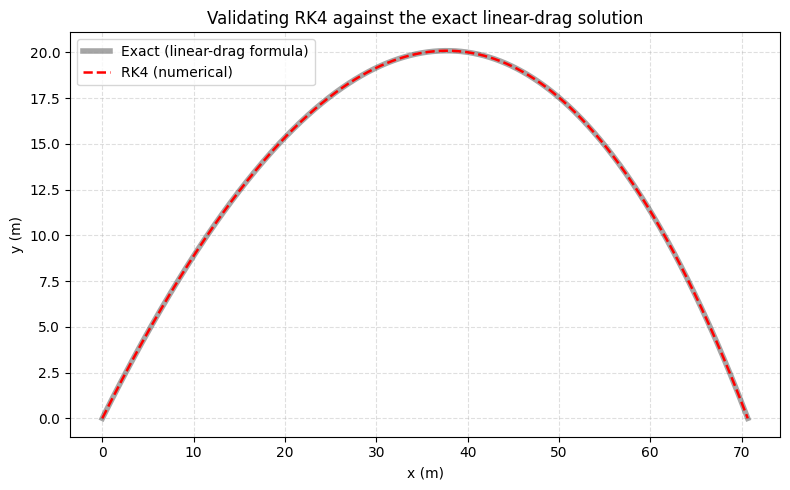

In [5]:
# ── Exact linear-drag solution (closed form) ──────────────────────────────────
def analytic_linear(t, u, theta_deg, k):
    th  = np.radians(theta_deg)
    vx0 = u*np.cos(th); vy0 = u*np.sin(th)
    e   = np.exp(-k*t)
    x = (vx0/k)*(1 - e)
    y = (1.0/k)*(vy0 + g/k)*(1 - e) - (g/k)*t
    return x, y

# Integrate the SAME case with RK4 (drag='linear') and compare to the formula.
u_t, th_t, k_t = 30.0, 45.0, 0.1
T,X,Y,VX,VY = integrate(u_t, th_t, k_t, drag='linear', dt=0.0005)
xa, ya = analytic_linear(T, u_t, th_t, k_t)

print("Max |RK4 - exact| over the whole flight:")
print(f"   x: {np.max(np.abs(X-xa)):.2e} m      y: {np.max(np.abs(Y-ya)):.2e} m")
print("   -> essentially zero: RK4 is trustworthy.")

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(xa, ya, 'k-',  lw=4, alpha=0.35, label='Exact (linear-drag formula)')
ax.plot(X,  Y,  'r--', lw=1.8,           label='RK4 (numerical)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Validating RK4 against the exact linear-drag solution')
ax.legend(); ax.grid(True, ls='--', alpha=0.4); plt.tight_layout(); plt.show()

## Validation result
I integrate a linear-drag case with RK4 and overlay the exact formula. If my integrator is
correct the two curves are indistinguishable and the maximum error is ~$10^{-7}$ m. Seeing
that tiny number is what lets me move on and trust RK4 everywhere else.

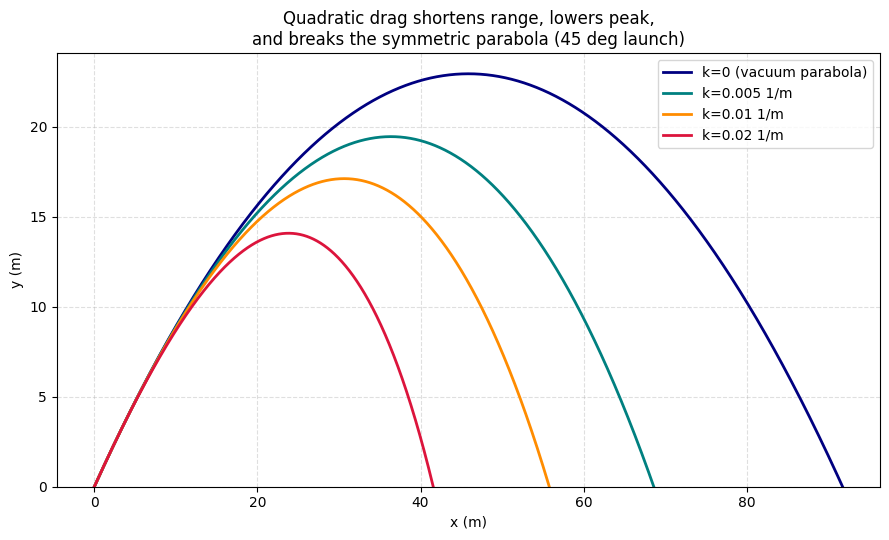

In [6]:
# ── Now LOOK at what quadratic drag does to the trajectory ────────────────────
# Compare the vacuum parabola (k=0) with increasing amounts of real air drag.
fig, ax = plt.subplots(figsize=(9,5.5))
for k_demo, col in [(0.0,'navy'), (0.005,'teal'), (0.01,'darkorange'), (0.02,'crimson')]:
    _,Xd,Yd,_,_ = integrate(u_fixed, 45.0, k_demo)
    label = 'k=0 (vacuum parabola)' if k_demo==0 else f'k={k_demo} 1/m'
    ax.plot(Xd, Yd, color=col, lw=2, label=label)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Quadratic drag shortens range, lowers peak,\nand breaks the symmetric parabola (45 deg launch)')
ax.legend(); ax.grid(True, ls='--', alpha=0.4); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

# Notice: with drag the curve is NO LONGER a symmetric parabola — the descent is
# steeper than the ascent. That asymmetry is exactly what has no closed-form formula.

## Looking at what drag actually does
Before modelling, I want to *see* the effect I'm trying to capture. I plot the vacuum parabola
($k=0$) next to increasingly draggy flights at the same launch angle. Drag shortens the range,
lowers the peak, and — crucially — **breaks the symmetry**: the descent is steeper than the
ascent, so the curve is no longer a parabola. That asymmetry is exactly the part that has no
formula and that my PINN will have to learn.

In [7]:
# ── Reference scales for normalisation ────────────────────────────────────────
# We take the "biggest" flight in our range (highest angle, no drag) to set the
# scales, so every normalised quantity lands in roughly [0, 1].
T_ref = integrate(u_fixed, theta_max, k_min)[0][-1]     # longest flight time
x_ref = integrate(u_fixed, 45.0,      k_min)[1].max()   # largest horizontal range
y_ref = integrate(u_fixed, theta_max, k_min)[2].max()   # largest peak height
theta_ref = 90.0                                        # angles normalised by 90 deg
k_ref     = max(k_max, 1e-6)                             # drag normalised by its max
v_ref     = u_fixed                                     # velocity scale (for IC loss)
print(f"T_ref={T_ref:.3f}s  x_ref={x_ref:.2f}m  y_ref={y_ref:.2f}m")

# ── Build the network input [t_norm, theta_norm, k_norm] from a PHYSICAL time ──
# t_raw is kept in seconds (and may carry requires_grad) so autograd differentiates
# with respect to real time; the /T_ref scaling rides along inside the graph.
def make_input(t_raw, theta_deg, k):
    t_norm     = t_raw / T_ref
    theta_norm = torch.full_like(t_raw, theta_deg / theta_ref)
    k_norm     = torch.full_like(t_raw, k / k_ref)
    return torch.cat([t_norm, theta_norm, k_norm], dim=1)   # shape [N, 3]

T_ref=5.543s  x_ref=91.74m  y_ref=37.68m


## My PINN design for the drag problem
**Why time-domain.** In Notebooks 1–2 I mapped $x\mapsto y$ because $y$ was a neat function
of $x$. With drag it's far cleaner to use **time** as the input:
$$ (t,\;\theta,\;k)\;\longmapsto\;(x,\;y). $$
Then velocities and accelerations come for free by differentiating the outputs with respect to
$t$ via autograd. The $\theta$ and $k$ inputs are what make it *generalised* — one model for a
whole family of drag flights.

**Normalisation and a chain-rule trick I'm relying on.** I scale every input and output to
roughly $[0,1]$ using reference scales (longest flight time, largest range, largest height).
The neat part: because $t_{\text{norm}}=t/T_{\text{ref}}$ lives inside the computation graph,
if I differentiate the network's output with respect to the **physical** time leaf, autograd
automatically carries the $1/T_{\text{ref}}$ factor. So I only multiply by the position scale
($x_{\text{ref}}$ or $y_{\text{ref}}$) to get a physical velocity. That keeps the physics
exact while the network still works in nicely-scaled numbers.

In [8]:
# ── The network ───────────────────────────────────────────────────────────────
# 3 inputs  -> [t_norm, theta_norm, k_norm]
# 2 outputs -> [x_norm, y_norm]
# Tanh activation: SMOOTH and infinitely differentiable. This is essential — a PINN
# differentiates the network TWICE, and ReLU's derivative is a step (2nd deriv = 0),
# which would make the physics loss meaningless. NEVER use ReLU in a PINN.
# 5 layers x 64 neurons: enough capacity to represent a 2-parameter family of curves.
class FCN(nn.Module):
    def __init__(self, N_INPUT=3, N_OUTPUT=2, N_HIDDEN=64, N_LAYERS=5):
        super().__init__()
        activation = nn.Tanh
        layers = [nn.Linear(N_INPUT, N_HIDDEN), activation()]
        for _ in range(N_LAYERS - 1):
            layers += [nn.Linear(N_HIDDEN, N_HIDDEN), activation()]
        layers += [nn.Linear(N_HIDDEN, N_OUTPUT)]   # output layer: NO activation
        self.net = nn.Sequential(*layers)
    def forward(self, z):
        return self.net(z)

pinn = FCN().to(device)
print(pinn)
print(f"Trainable parameters: {sum(p.numel() for p in pinn.parameters())}")

FCN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)
Trainable parameters: 17026


## The network
Three inputs $[t,\theta,k]$, two outputs $[x,y]$, 5 layers of 64 neurons, `Tanh` throughout
(I differentiate twice, so I need smoothness). The output layer has no activation since
positions are unbounded reals.

In [9]:
# ── Precompute a flight-time lookup table (so training stays fast) ────────────
# We need each config's flight time T_f for the landing anchor and the collocation
# time range [0, T_f]. Re-running RK4 every training step would be far too slow, so
# we integrate ONCE on a (theta, k) grid and bilinearly interpolate during training.
TH_GRID = np.linspace(theta_min, theta_max, 21)
K_GRID  = np.linspace(k_min,     k_max,     21)
FT_TABLE = np.array([[integrate(u_fixed, th, k)[0][-1] for k in K_GRID]
                                                       for th in TH_GRID])
print("Flight-time table built:", FT_TABLE.shape)

def flight_time(theta_deg, k):
    th = np.clip(theta_deg, TH_GRID[0], TH_GRID[-1])
    kk = np.clip(k,         K_GRID[0],  K_GRID[-1])
    i = np.clip(np.searchsorted(TH_GRID, th)-1, 0, len(TH_GRID)-2)
    j = np.clip(np.searchsorted(K_GRID,  kk)-1, 0, len(K_GRID)-2)
    fa = (th-TH_GRID[i])/(TH_GRID[i+1]-TH_GRID[i])
    fb = (kk-K_GRID[j]) /(K_GRID[j+1] -K_GRID[j])
    return (FT_TABLE[i,j]*(1-fa)*(1-fb) + FT_TABLE[i+1,j]*fa*(1-fb)
          + FT_TABLE[i,j+1]*(1-fa)*fb   + FT_TABLE[i+1,j+1]*fa*fb)

# ── Helper: first derivative of a network output w.r.t. the time leaf ─────────
# create_graph=True keeps the graph alive so we can differentiate AGAIN (2nd deriv).
def d_dt(output, t_leaf):
    return torch.autograd.grad(output, t_leaf,
                               grad_outputs=torch.ones_like(output),
                               create_graph=True)[0]

num_pairs_per_epoch = 16     # how many random (theta, k) flights per training step
num_col_per_pair    = 80     # physics-enforcement points per flight

def compute_losses():
    loss_ic_pos = torch.tensor(0.0, device=device)
    loss_ic_vel = torch.tensor(0.0, device=device)
    loss_bc     = torch.tensor(0.0, device=device)
    loss_phys   = torch.tensor(0.0, device=device)

    for _ in range(num_pairs_per_epoch):
        th = np.random.uniform(theta_min, theta_max)     # random launch angle
        k  = np.random.uniform(k_min,     k_max)         # random drag coefficient
        thr = np.radians(th)
        vx0, vy0 = u_fixed*np.cos(thr), u_fixed*np.sin(thr)
        Tf = flight_time(th, k)                          # this flight's duration

        # (a)+(b) INITIAL CONDITIONS at t=0 ----------------------------------
        t0 = torch.zeros(1, 1, requires_grad=True, device=device)
        o0 = pinn(make_input(t0, th, k))
        x0, y0 = o0[:, 0:1], o0[:, 1:2]
        loss_ic_pos = loss_ic_pos + torch.mean(x0**2) + torch.mean(y0**2)
        vx0_pred = d_dt(x0, t0) * x_ref                  # physical dx/dt at t=0
        vy0_pred = d_dt(y0, t0) * y_ref                  # physical dy/dt at t=0
        loss_ic_vel = loss_ic_vel + torch.mean(((vx0_pred-vx0)/v_ref)**2) \
                                  + torch.mean(((vy0_pred-vy0)/v_ref)**2)

        # (c) LANDING ANCHOR: y(Tf)=0 ----------------------------------------
        tb = torch.full((1, 1), Tf, device=device)       # no grad needed (value only)
        yb = pinn(make_input(tb, th, k))[:, 1:2]
        loss_bc = loss_bc + torch.mean(yb**2)

        # (d) PHYSICS RESIDUAL at random times in [0, Tf] --------------------
        tc = (torch.rand(num_col_per_pair, 1, device=device) * Tf).requires_grad_(True)
        oc = pinn(make_input(tc, th, k))
        xc, yc = oc[:, 0:1], oc[:, 1:2]
        vx = d_dt(xc, tc) * x_ref                         # velocities (physical)
        vy = d_dt(yc, tc) * y_ref
        ax = d_dt(vx, tc)                                 # accelerations (physical)
        ay = d_dt(vy, tc)
        v  = torch.sqrt(vx*vx + vy*vy + 1e-12)            # speed (eps avoids /0 in grad)
        Rx = ax + k*v*vx                                  # should be 0
        Ry = ay + k*v*vy + g                              # should be 0
        loss_phys = loss_phys + torch.mean((Rx/g)**2) + torch.mean((Ry/g)**2)

    n = num_pairs_per_epoch
    return loss_ic_pos/n, loss_ic_vel/n, loss_bc/n, loss_phys/n

Flight-time table built: (21, 21)


## My loss function — encoding an ODE *system* with no data
Just like before, the PINN trains on physics, not examples. I add four penalties:
- **(a) Initial position:** $x(0)=y(0)=0$ (normalised).
- **(b) Initial velocity:** $\dot x(0)=u\cos\theta,\ \dot y(0)=u\sin\theta$, each normalised by
  $u$ so the term is order 1.
- **(c) Landing anchor:** $y(T_f)=0$ at the RK4-known flight time — the drag analogue of the
  "lands at $x_{\max}$" condition from Notebook 2.
- **(d) Physics residual:** the heart of it. At many random times I demand the network's own
  derivatives obey the equations of motion, with residuals $R_x=\ddot x+k v\dot x$ and
  $R_y=\ddot y+k v\dot y+g$, each normalised by $g$.

**Why I normalise each term:** positions are tens of metres, accelerations are m/s², velocities
tens of m/s. If I summed the raw squares, the biggest-numbered term would dominate and the
others would be ignored. Dividing each by its natural scale ($u$, $g$) makes every term order
1, so my loss *weights* actually express priorities rather than secretly being unit conversions.

**One engineering choice:** I need each flight's duration $T_f$ constantly, and re-running RK4
every training step would be far too slow, so I precompute a **flight-time lookup table** once
on a $(\theta,k)$ grid and bilinearly interpolate during training.

In [10]:
# ── Loss weights (priorities; see the markdown above for the reasoning) ───────
w_ic_pos = 20.0     # start exactly at the origin
w_ic_vel = 20.0     # leave at exactly the launch velocity
w_bc     = 10.0     # come back to the ground at the right time
w_phys   = 10.0     # obey the drag equations in between

num_epochs = 6000   # on a Colab GPU this is a few minutes; raise for higher accuracy
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Bookkeeping for the loss curves
hist = {'ic_pos':[], 'ic_vel':[], 'bc':[], 'phys':[], 'total':[]}

# Snapshot a few test flights at checkpoints to watch the PINN learn
checkpoints  = [0, num_epochs//4, num_epochs//2, num_epochs-1]
snap_configs = [(35.0, 0.0), (45.0, 0.01), (55.0, 0.018)]   # (theta, k) to track
snapshots    = {cfg: [] for cfg in snap_configs}

print("Training...")
print(f"{'Epoch':>6} {'Total':>10} {'IC pos':>10} {'IC vel':>10} {'BC':>10} {'Physics':>10}")
for epoch in range(num_epochs):
    optimizer.zero_grad()
    l_icp, l_icv, l_bc, l_ph = compute_losses()
    loss = w_ic_pos*l_icp + w_ic_vel*l_icv + w_bc*l_bc + w_phys*l_ph
    loss.backward()
    optimizer.step()
    scheduler.step()

    hist['ic_pos'].append(l_icp.item()); hist['ic_vel'].append(l_icv.item())
    hist['bc'].append(l_bc.item());      hist['phys'].append(l_ph.item())
    hist['total'].append(loss.item())

    if epoch in checkpoints:
        pinn.eval()
        for cfg in snap_configs:
            th_s, k_s = cfg
            T_s, X_s, Y_s, _, _ = integrate(u_fixed, th_s, k_s)
            with torch.no_grad():
                t_t = torch.tensor(T_s, dtype=torch.float32, device=device).unsqueeze(1)
                o   = pinn(make_input(t_t, th_s, k_s))
                xp  = o[:, 0].cpu().numpy()*x_ref
                yp  = o[:, 1].cpu().numpy()*y_ref
            snapshots[cfg].append({'epoch':epoch, 'X':X_s, 'Y':Y_s, 'xp':xp, 'yp':yp})
        pinn.train()

    if epoch % 500 == 0 or epoch == num_epochs-1:
        print(f"{epoch:>6} {loss.item():>10.3e} {l_icp.item():>10.3e} "
              f"{l_icv.item():>10.3e} {l_bc.item():>10.3e} {l_ph.item():>10.3e}")
print("Training complete.")

Training...
 Epoch      Total     IC pos     IC vel         BC    Physics
     0  3.033e+01  1.552e-02  9.953e-01  1.162e-02  9.996e-01
   500  1.095e-01  1.437e-03  1.076e-03  1.627e-03  4.296e-03
  1000  3.201e-02  4.168e-04  5.147e-04  3.481e-04  9.904e-04
  1500  2.223e-02  2.273e-04  2.865e-04  6.795e-04  5.154e-04
  2000  1.928e-02  2.678e-04  1.245e-04  7.657e-04  3.779e-04
  2500  3.543e-02  4.621e-04  2.691e-04  1.643e-03  4.374e-04
  3000  6.095e-03  2.847e-05  5.726e-05  9.705e-05  3.409e-04
  3500  5.949e-03  6.433e-05  4.654e-05  1.218e-04  2.513e-04
  4000  5.656e-03  2.850e-05  2.620e-05  2.064e-04  2.498e-04
  4500  4.607e-03  2.743e-05  4.189e-05  2.562e-05  2.964e-04
  5000  2.604e-03  1.876e-05  2.308e-05  2.887e-05  1.479e-04
  5500  6.517e-03  3.500e-05  6.514e-05  5.563e-05  3.958e-04
  5999  3.184e-03  1.658e-05  1.225e-05  6.739e-05  1.934e-04
Training complete.


## My training strategy and the reasoning behind every knob
- **Optimiser = Adam**, robust default for the messy multi-term PINN loss.
- **Learning rate $10^{-3}$, cosine-annealed to $10^{-5}$:** start fast to find the right
  region, then slow down to settle precisely instead of bouncing around the minimum.
- **Loss weights** express priorities (because every term is already order 1): the initial
  conditions and landing must hold almost exactly, so I weight them 10–20; the physics residual
  is the hardest term to zero out and is enforced at thousands of points, so I keep it
  meaningful too. My tuning rule of thumb: if the *start* drifts, raise the IC weights; if the
  *shape* is wrong, raise physics; if it *overshoots the landing*, raise the BC weight.
- **Fresh random $(\theta,k)$ and collocation times every epoch** ("on-the-fly" data) so the
  network sees huge variety and can't memorise.

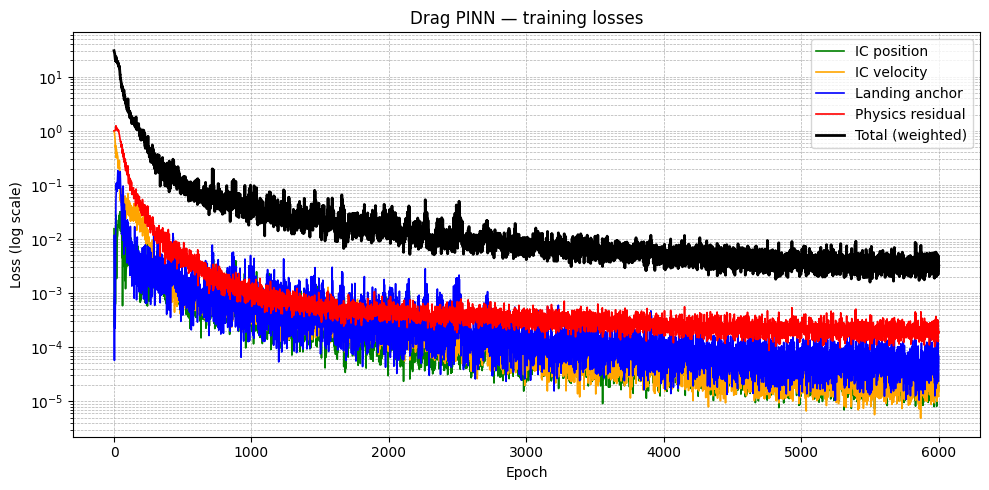

In [11]:
# ── Training-loss curves (log scale) ─────────────────────────────────────────
ep = np.arange(num_epochs)
plt.figure(figsize=(10,5))
plt.plot(ep, hist['ic_pos'], label='IC position', lw=1.2, color='green')
plt.plot(ep, hist['ic_vel'], label='IC velocity', lw=1.2, color='orange')
plt.plot(ep, hist['bc'],     label='Landing anchor', lw=1.2, color='blue')
plt.plot(ep, hist['phys'],   label='Physics residual', lw=1.2, color='red')
plt.plot(ep, hist['total'],  label='Total (weighted)', lw=2.0, color='black')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss (log scale)')
plt.title('Drag PINN — training losses')
plt.legend(); plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

## Training curves
Every loss term on a log scale. I expect the initial-condition terms to drop fast and the
physics residual to be the slow, dominant term — with drag there's simply more to satisfy than
in the vacuum case.

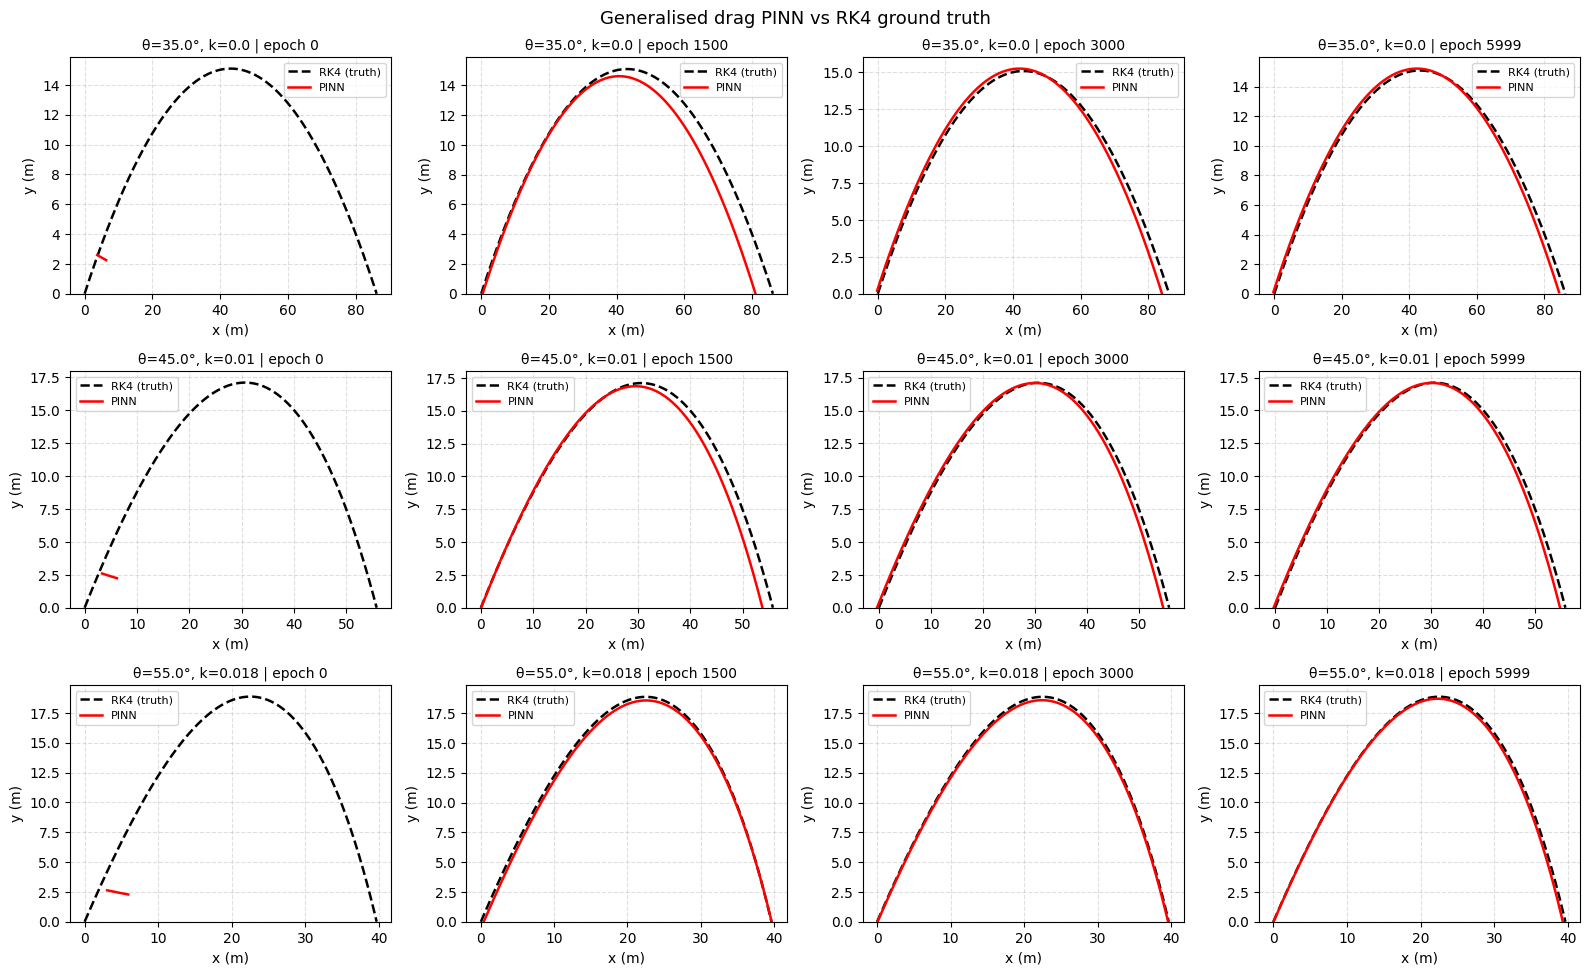

In [12]:
# ── Watch the PINN converge: rows = test flights, columns = checkpoints ───────
n_rows, n_cols = len(snap_configs), len(checkpoints)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.3*n_rows))
for r, cfg in enumerate(snap_configs):
    th_s, k_s = cfg
    for c, snap in enumerate(snapshots[cfg]):
        ax = axes[r][c] if n_rows>1 else axes[c]
        ax.plot(snap['X'], snap['Y'], 'k--', lw=1.8, label='RK4 (truth)')
        ax.plot(snap['xp'], snap['yp'], 'r-', lw=1.8, label='PINN')
        ax.set_title(f"θ={th_s}°, k={k_s} | epoch {snap['epoch']}", fontsize=10)
        ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
        ax.set_ylim(bottom=0); ax.grid(True, ls='--', alpha=0.4); ax.legend(fontsize=8)
plt.suptitle('Generalised drag PINN vs RK4 ground truth', fontsize=13)
plt.tight_layout(); plt.show()

## Watching the drag PINN converge against RK4
Rows are three test flights, columns are checkpoints. The dashed black curve is my RK4 truth,
the red is the PINN. What I'm checking is that the network captures the *asymmetric* drag
shape (steeper descent), not just a generic arc — and that all three very different flights
converge, not just one.

In [13]:
# ── Sweep (theta, k), compute RMSE % vs RK4 at each point ─────────────────────
n_th, n_k = 22, 22
theta_sweep = np.linspace(theta_min-5, theta_max+5, n_th)   # extend beyond training
k_sweep     = np.linspace(max(k_min,0), k_max+0.005, n_k)
rmse_grid   = np.full((n_th, n_k), np.nan)

threshold = 5.0   # we call <5% RMSE "accurate"
pinn.eval()
with torch.no_grad():
    for i, th_s in enumerate(theta_sweep):
        for j, k_s in enumerate(k_sweep):
            if not (0 < th_s < 90):
                continue
            T_s, X_s, Y_s, _, _ = integrate(u_fixed, th_s, k_s)
            t_t = torch.tensor(T_s, dtype=torch.float32, device=device).unsqueeze(1)
            yp  = pinn(make_input(t_t, th_s, k_s))[:, 1].cpu().numpy()*y_ref
            y_peak = max(Y_s.max(), 1e-6)
            rmse_grid[i, j] = np.sqrt(np.mean((yp - Y_s)**2)) / y_peak * 100

print("Sensitivity results:")
print(f"  mean RMSE over grid : {np.nanmean(rmse_grid):.2f}%")
print(f"  best / worst        : {np.nanmin(rmse_grid):.2f}% / {np.nanmax(rmse_grid):.2f}%")
print(f"  fraction below {threshold:.0f}%  : {100*np.nanmean(rmse_grid<threshold):.1f}%")

Sensitivity results:
  mean RMSE over grid : 1.91%
  best / worst        : 0.10% / 18.61%
  fraction below 5%  : 91.3%


## Sensitivity analysis — where does my model actually hold up?
A single accuracy number hides the truth, so I sweep the whole $(\theta,k)$ plane — with a
margin *outside* the training box — and record the RMSE (as a percentage of peak height)
against RK4 at every point. My expectations: a low-error region inside the training box; error
growing once I leave it (PINNs extrapolate poorly, since physics was only enforced inside); and
the hardest corner being high drag + steep angle, where the trajectory is most sharply curved
and most asymmetric.

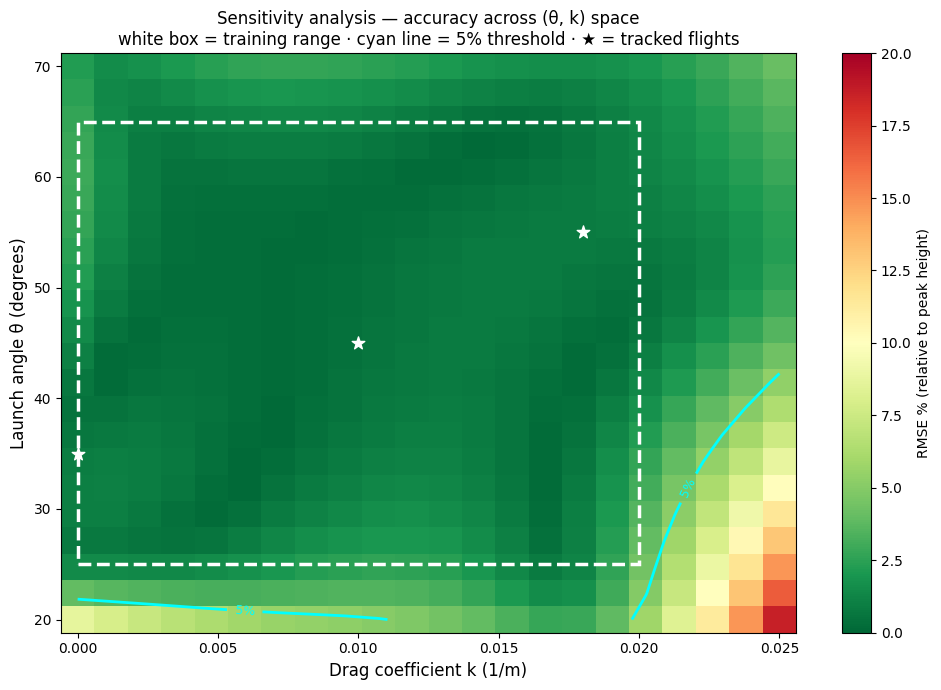

In [14]:
# ── Heatmap of accuracy across (theta, k) space ───────────────────────────────
fig, ax = plt.subplots(figsize=(10,7))
im = ax.pcolormesh(k_sweep, theta_sweep, rmse_grid,
                   cmap=plt.cm.RdYlGn_r, vmin=0, vmax=20, shading='auto')
cbar = plt.colorbar(im, ax=ax, label='RMSE % (relative to peak height)')

# white dashed box = the region the network was actually trained on
rect = plt.Rectangle((k_min, theta_min), k_max-k_min, theta_max-theta_min,
                     lw=2.5, edgecolor='white', facecolor='none', ls='--',
                     label='Training range')
ax.add_patch(rect)

# cyan contour at the 5% "accurate" threshold
cs = ax.contour(k_sweep, theta_sweep, rmse_grid, levels=[threshold],
                colors='cyan', linewidths=2)
ax.clabel(cs, fmt='%.0f%%', fontsize=9, colors='cyan')

# mark the flights we tracked during training
for (th_t, k_t) in snap_configs:
    ax.scatter(k_t, th_t, color='white', s=90, marker='*', zorder=5)

ax.set_xlabel('Drag coefficient k (1/m)', fontsize=12)
ax.set_ylabel('Launch angle θ (degrees)', fontsize=12)
ax.set_title('Sensitivity analysis — accuracy across (θ, k) space\n'
             'white box = training range · cyan line = 5% threshold · ★ = tracked flights')
plt.tight_layout(); plt.show()

## The accuracy map
Green = accurate, red = not; white box = training range; cyan line = my 5% threshold; stars =
the flights I tracked during training. This is the honest summary of what my drag PINN can and
can't be trusted to do.

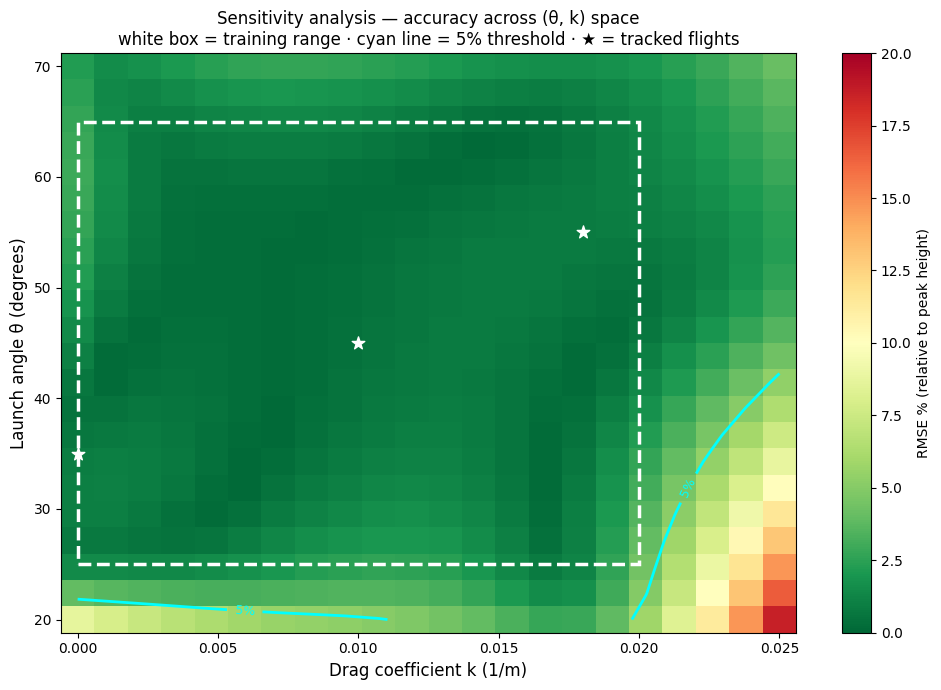

In [15]:
# ── Heatmap of accuracy across (theta, k) space ───────────────────────────────
fig, ax = plt.subplots(figsize=(10,7))
im = ax.pcolormesh(k_sweep, theta_sweep, rmse_grid,
                   cmap=plt.cm.RdYlGn_r, vmin=0, vmax=20, shading='auto')
cbar = plt.colorbar(im, ax=ax, label='RMSE % (relative to peak height)')

# white dashed box = the region the network was actually trained on
rect = plt.Rectangle((k_min, theta_min), k_max-k_min, theta_max-theta_min,
                     lw=2.5, edgecolor='white', facecolor='none', ls='--',
                     label='Training range')
ax.add_patch(rect)

# cyan contour at the 5% "accurate" threshold
cs = ax.contour(k_sweep, theta_sweep, rmse_grid, levels=[threshold],
                colors='cyan', linewidths=2)
ax.clabel(cs, fmt='%.0f%%', fontsize=9, colors='cyan')

# mark the flights we tracked during training
for (th_t, k_t) in snap_configs:
    ax.scatter(k_t, th_t, color='white', s=90, marker='*', zorder=5)

ax.set_xlabel('Drag coefficient k (1/m)', fontsize=12)
ax.set_ylabel('Launch angle θ (degrees)', fontsize=12)
ax.set_title('Sensitivity analysis — accuracy across (θ, k) space\n'
             'white box = training range · cyan line = 5% threshold · ★ = tracked flights')
plt.tight_layout(); plt.show()

## What I take away from Notebook 3
- Drag makes the equations **nonlinear and unsolvable in closed form**, so I built **RK4** as
  my numerical truth and *proved* it correct against the exact linear-drag solution.
- I switched to a **time-domain PINN** $(t,\theta,k)\mapsto(x,y)$ trained with **no data** —
  only initial conditions, a landing anchor, and a physics residual built from its own autograd
  derivatives — with careful normalisation keeping every loss term comparable.
- The sensitivity map showed where the surrogate is trustworthy and how it degrades.
- **Next:** so far every notebook has gone *forwards* (physics $\to$ trajectory). In Notebooks
  4 and 5 I flip the problem around — given noisy trajectory *observations*, can a PINN
  **discover the hidden physical parameters**? That's an inverse, or "reverse", PINN.